# Bayesian vs Frequentist Logistic Regression

In [3]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from sklearn.linear_model import LogisticRegression
import pymc as pm # changed this since pymc3 wasn't working
import zipfile

## The Dataset

You can download the dataset from here: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [5]:
## 1 point

## ToDo: read the csv file into a dataframe and show the first 5 rows

# Unzip the archive.zip
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Load diabetes.csv into a dataframe
diab_df = pd.read_csv('diabetes.csv')
diab_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
## 3 points

## Assign the Outcome variable to y and the rest to X.
y = diab_df['Outcome']
X = diab_df.drop('Outcome', axis=1)
# print(X.head())
# print(y.head())

## USe LogisticRegression to fit the data and print out the intercept and the coefficients
logreg = LogisticRegression(max_iter=1000) # This wasn't converging with the default number of iterations, hence increased to 1000
logreg.fit(X, y)
print('Intercept:', logreg.intercept_)
print('Coefficients:', logreg.coef_)

Intercept: [-8.36470855]
Coefficients: [[ 1.22481312e-01  3.51085717e-02 -1.33007000e-02  7.81917450e-04
  -1.17386223e-03  8.96453133e-02  8.68084149e-01  1.49863097e-02]]


In [14]:
## 2 points

# Explain what the code is doing:
## What are the prior probabilities of the intercept and coefficients?
## Which likelihood distribution has been used?
## What does pm.invlogit(linreg) mean?
## What is map_est?

with pm.Model() as logreg_model:              # creates a vanilla pymc model context called logreg_model

    # Original
    # w0 = pm.Normal('w0', mu=0, sd=100)
    # w1 = pm.Normal('w1', mu=0, sd=100)
    # w2 = pm.Normal('w2', mu=0, sd=100)
    # w3 = pm.Normal('w3', mu=0, sd=100)
    # w4 = pm.Normal('w4', mu=0, sd=100)
    # w5 = pm.Normal('w5', mu=0, sd=100)
    # w6 = pm.Normal('w6', mu=0, sd=100)
    # w7 = pm.Normal('w7', mu=0, sd=100)
    # w8 = pm.Normal('w8', mu=0, sd=100)

    # Modified to work with new pymc5, keyword for standard deviation changed to sigma

    # It is a series of normal distributions with mean of 0 and standard deviation of 100
    w0 = pm.Normal('w0', mu=0, sigma=100)     # multiplied against np.ones() below and is hence the intercept
    w1 = pm.Normal('w1', mu=0, sigma=100)     # multiplied against diab_df.Pregnancies as it's coefficient
    w2 = pm.Normal('w2', mu=0, sigma=100)     # multiplied against diab_df.Glucose as it's coefficient
    w3 = pm.Normal('w3', mu=0, sigma=100)     # multiplied against diab_df.BloodPressure as it's coefficient
    w4 = pm.Normal('w4', mu=0, sigma=100)     # multiplied against diab_df.SkinThickness as it's coefficient
    w5 = pm.Normal('w5', mu=0, sigma=100)     # multiplied against diab_df.Insulin as it's coefficient
    w6 = pm.Normal('w6', mu=0, sigma=100)     # multiplied against diab_df.BMI as it's coefficient
    w7 = pm.Normal('w7', mu=0, sigma=100)     # multiplied against diab_df.DiabetesPedigreeFunction as it's coefficient
    w8 = pm.Normal('w8', mu=0, sigma=100)     # multiplied against diab_df.Age as it's coefficient

    # This is the linear regression calculation
    linreg = w0 * np.ones(diab_df.shape[0]) + w1 * diab_df.Pregnancies.values + w2 * diab_df.Glucose.values \
    + w3 * diab_df.BloodPressure.values + w4 * diab_df.SkinThickness.values + w5 * diab_df.Insulin.values + \
    w6 * diab_df.BMI.values + w7 * diab_df.DiabetesPedigreeFunction.values + w8 * diab_df.Age.values

    # The inverse logit or sigmoid to the calulcated value of the linear regression in order to predict 0 and 1 instead of decimals
    p_outcome = pm.invlogit(linreg)

    # Likelihood distribution represented as a Bernoulli distribution due to the binary nature of Diabetes
    likelihood = pm.Bernoulli('likelihood', p_outcome, observed=diab_df.Outcome.values)

    # Maximum A Posteriori
    map_est= pm.find_MAP()
    print(map_est)

Output()

{'w0': array(-8.40468431), 'w1': array(0.12319422), 'w2': array(0.0351628), 'w3': array(-0.01329664), 'w4': array(0.00060659), 'w5': array(-0.0011912), 'w6': array(0.08971064), 'w7': array(0.9455878), 'w8': array(0.01486419)}


# Explanation

## What are the prior probabilities of the intercept and coefficients?
The prior probabilities of the intercept are all normal distributions with an average of 0 and a standard deviation of 100. The intercept is `w0` while the coefficients are `w1 - w8`.

## Which likelihood distribution has been used?
The Bernoulli distribution.

## What does pm.invlogit(linreg) mean?
It stands for 'Inverse Logit' and is just a sigmoid function to get 1's and 0's from the resulting `linreg`.

## What is map_est?
`map_est` stands for 'Maximum A Posteriori Estimate'. From my understanding it takes the updated posterior distribution with our updated beliefs and gets a point estimate by finding the mode. Hence, it is just a point estimate that maximizes the posterior distribution.

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


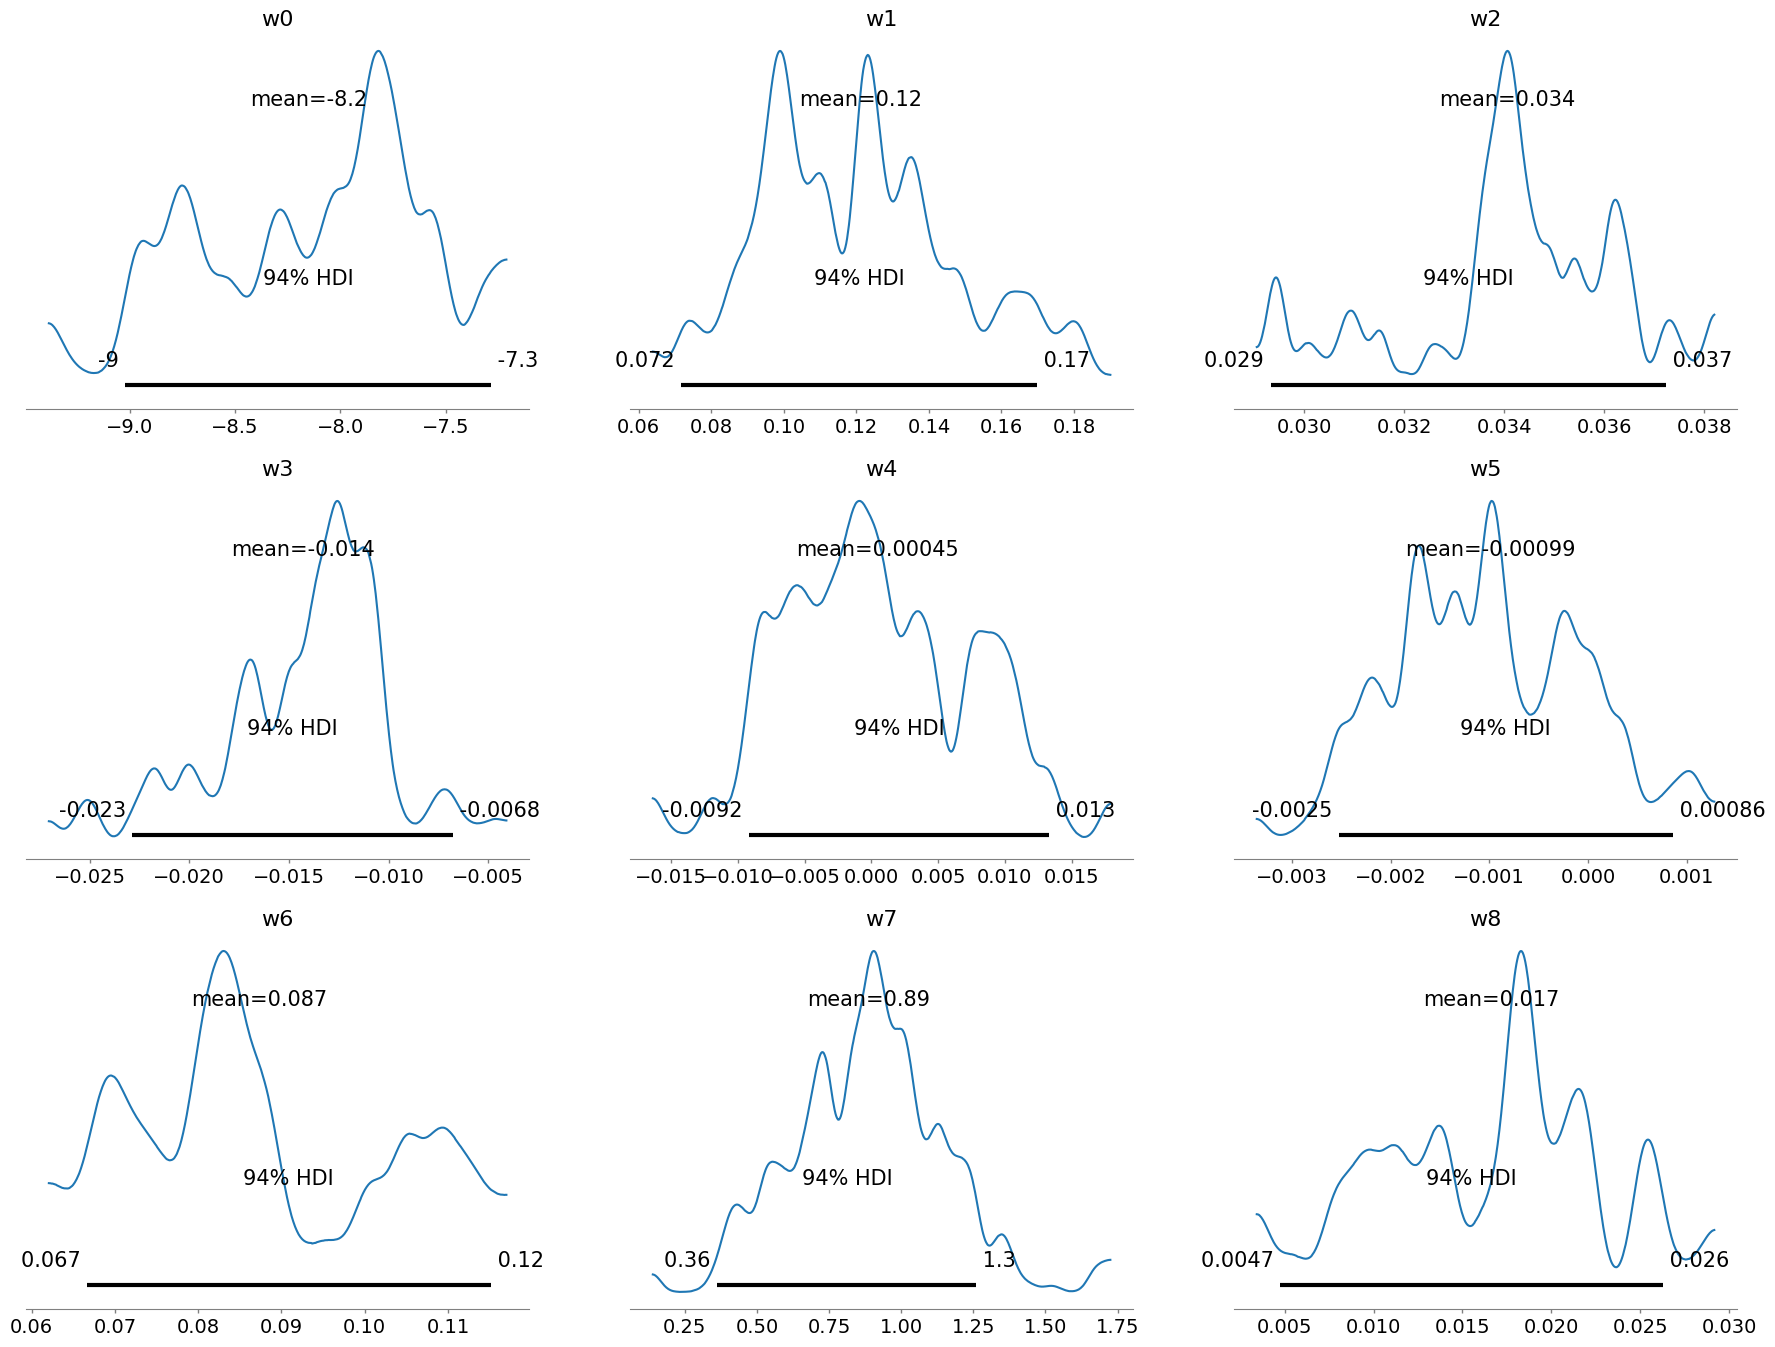

In [16]:
## 2 points

with logreg_model:
  ## ToDo: draw 400 samples using pm.Metropolis() and assign to the variable trace
  trace = pm.sample(400, tune=1000, step=pm.Metropolis())

  ## Explain the output of the plot
  az.plot_posterior(trace)

## Explanation
The plots show the graphs for the distributions `w0 - w8`. The `pm.Metropolis()` is the Metropolis-Hastings algorithm which is a type of Markov Chain Monte Carlo sampling algorithm.

In this case, it is randomly generating the intercept and weights, randomly altering the intercepts and weights a little bit each iteration, evaluating, and drawing a graph based on the 400 samples to visualize the posterior distribution.

The impact of these plots can be looked at as a weighting for which factors contribute the most to Diabetes in Indians. This is because the larger the coefficient the more it contributes to increasing the sigmoid function closer to 1 for a positive diabetes diagnosis. We can see that the mean for all the coefficients are significantly smaller than the greatest one at 0.89 for Diabetes Pedigree Function. This suggests that genetics is a large contributing factor to the diagnosis of diabetes.